# **Understanding what Machine Learning can do with Dynamic Systems**

- In this report I will attempting at least to construct a phase portrait ODE while also experimenting with the **model** on how machine learning can enhance my findings in complex formulas
    - We will be using the data sheet from "Lake Powell FIsheries Data" from `Kaggle` website for predicting our predator-prey ODE model for this lesson
    - The report will be split into `8` sections each progressing how we can use machine learning to predict what will our fish population will occur in 15 years to the future and see if we can recreate a phase portrait

## **1. Libraries and Dataset loader**


#### Everything we will be using for this report include using `Torch Version: 2.11 CU: 128` for our analysis.

In [189]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch 
import torch.nn as nn
import torch.optim as optim
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
import pandas as pd

print("Libraries imported successfully!")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU Name: NVIDIA GeForce RTX 5070
Libraries imported successfully!


#### Running basic command to see if our dataset has been installed successfully (It works)

In [190]:
files = ['AGE_GROW_TABLE.csv', 'FISH_TABLE.csv', 'LAB_COUNTS.csv', 'STOMACH_TABLE.csv']

for file in files:
    try:
        data = pd.read_csv(file, nrows=5)
        print(f"Successfully loaded {file}")
        print(data.columns.tolist())
    except Exception as e:
        print(f"Error loading {file}: {e}")

Successfully loaded AGE_GROW_TABLE.csv
['FISH_ID', 'TL', 'Season', 'AGE', 'Radius', 'AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12', 'AGE13', 'AGE14', 'AGE15']
Successfully loaded FISH_TABLE.csv
['FISH_ID', 'DATE', 'TREND', 'GEAR', 'Species', 'GENDER', 'TL', 'WT', 'KTL', 'Wr', 'MATURITY', 'AGE_STRUCTURE', 'STOMACH', 'GONADS', 'FAT_INDEX', 'PARASITE', 'MISC1_TEXT', 'MISC2_NUMBER', 'MISC3_TEXT', 'MISC4_NUMBER', 'SITE', 'KFL']
Successfully loaded LAB_COUNTS.csv
['ID', 'DATE', 'TIME', 'SECCHI', '.SAMPLES', 'STATION', 'NET_DIA', 'TEMP', 'ROT_1C1', 'ROT_1C2', 'ROT_1C3', 'ROT_1AVe', 'ROT_1', 'ACOP_1C1', 'ACOP_1C2', 'ACOP_1C3', 'ACOP_1AVE', 'ACOP_1', 'NCOP_1C1', 'NCOP_1C2', 'NCOP_1C3', 'NCOP_1AVE', 'NCOP_1', 'CLAD_1C1', 'CLAD_1C2', 'CLAD_1C3', 'CLAD_1AVE', 'CLAD_1', 'BOS_1C1', 'BOS_1C2', 'BOS_1C3', 'BOS_1AVE', 'BOS_1', 'OTH_1C1', 'OTH_1C2', 'OTH_1C3', 'OTH_1AVE', 'OTH_1', 'TOT_1', 'DEPTH_1', 'CELL_VOL1', 'ROT_2C1', 'ROT_2C2', 'ROT_2C3', 'ROT_2A

In [191]:
print("Data loading")

fish_df = pd.read_csv('FISH_TABLE.csv', low_memory=False)
age_df = pd.read_csv('AGE_GROW_TABLE.csv', low_memory=False)
stomach_df = pd.read_csv('STOMACH_TABLE.csv', low_memory=False)
lab_df = pd.read_csv('LAB_COUNTS.csv', low_memory=False)
print("Data loaded successfully!")


Data loading
Data loaded successfully!


## **2. Merging and combining our data**
- The main reason we do this to prevent overfitting and repeating such IDs into the same data value and will show off a better matrix and dataset for a bigger file

In [192]:
fish_df['DATE'] = pd.to_datetime(fish_df['DATE'], errors='coerce')
fish_df['Year'] = fish_df['DATE'].dt.year
id_to_year = fish_df.set_index('FISH_ID')['Year'].to_dict()

age_df['Year'] = age_df['FISH_ID'].map(id_to_year)
stomach_df['Year'] = stomach_df['FISH_ID'].map(id_to_year)

fish_yr = fish_df.groupby('Year').agg({'WT': 'mean', 'TL': 'mean'})
age_yr = age_df.groupby('Year').agg({'AGE': 'mean'})
stomach_yr = stomach_df.groupby('Year').agg({'ZOOPLANKTON': 'mean'})

lab_df['DATE'] = pd.to_datetime(lab_df['DATE'], errors='coerce')
lab_df['Year'] = lab_df['DATE'].dt.year
lab_df['TEMP'] = pd.to_numeric(lab_df['TEMP'], errors='coerce')
lab_df['TOT_AVE'] = pd.to_numeric(lab_df['TOT_AVE'], errors='coerce')
lab_yearly = lab_df.groupby('Year').agg({'TEMP': 'mean', 'TOT_AVE': 'mean'})

ts_full = pd.concat([fish_yr, age_yr, stomach_yr, lab_yearly], axis=1)
ts_recent = ts_full.loc[1999:2018].copy()

ts_recent = ts_recent.interpolate(method='linear').bfill().ffill()

## **3. Matrix Correlation**
- The matrix shows a fair accuracy to the correlation between our timeline

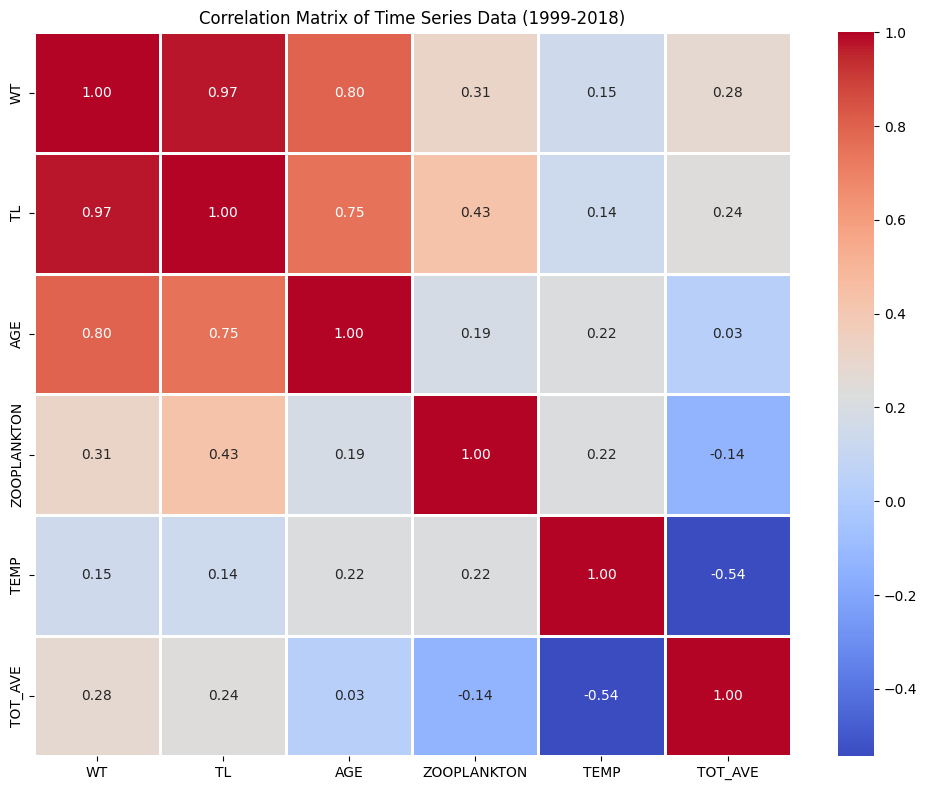

In [193]:
plt.figure(figsize=(10, 8))
corr_matrix = ts_recent.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Matrix of Time Series Data (1999-2018)')
plt.tight_layout()
plt.show()

## **4. Model Setup**
- The bread and butter for this we will be using a NN model with `Tahn` instead of `ReLU` for this in order to project a better prediction
- When running initial tests with `ReLU`, the Torch model became chaotic with high/low predictions messing up anyway to predict.
- Thus we chose `Tahn` instead of `ReLU`, with weight decay and higher learning rate

In [194]:
state_cols = ['WT', 'TEMP', 'TOT_AVE']
X_data = ts_recent[state_cols].values

X_min = X_data.min(axis=0)
X_max = X_data.max(axis=0) * 1.2
X_norm = (X_data - X_min) / (X_max - X_min + 1e-8)

dX_norm = np.gradient(X_norm, axis=0)

X_tensor = torch.tensor(X_norm, dtype=torch.float32)
dX_tensor = torch.tensor(dX_norm, dtype=torch.float32)

class EcosystemDynamicsNN(nn.Module):
    def __init__(self):
        super(EcosystemDynamicsNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 3)
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model = EcosystemDynamicsNN()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.MSELoss()

print("Starting training...")
for epoch in range(2500):
    optimizer.zero_grad()
    predictions = model(X_tensor)
    loss = criterion(predictions, dX_tensor)
    loss.backward()
    optimizer.step()

print("Training completed!")


Starting training...
Training completed!


### **This will be our next step in predicting the future cause of the predator-prey model by `15` years**

In [195]:
num_future_steps = 15
dt = 1.0
steps_per_year = int(1.0 / dt)

current_state = X_tensor[-1].unsqueeze(0)
projected_states_norm = [current_state.detach().numpy().flatten()]

model.eval()
with torch.no_grad():
    for year in range(num_future_steps):
        state_accum = current_state
        for step in range(steps_per_year):
            derivative = model(state_accum)
            state_accum = state_accum + (derivative * dt)
        
        state_accum = torch.clamp(state_accum, min=0.0, max=1.2)
        
        projected_states_norm.append(state_accum.numpy().flatten())
        current_state = state_accum

projected_states_norm = np.array(projected_states_norm)
projected_states = projected_states_norm * (X_max - X_min) + X_min

## **5. Plotting our initial Results**
- From our datasets the model shows some correlation to population rise and decay overtime when the predator-prey fluctuate

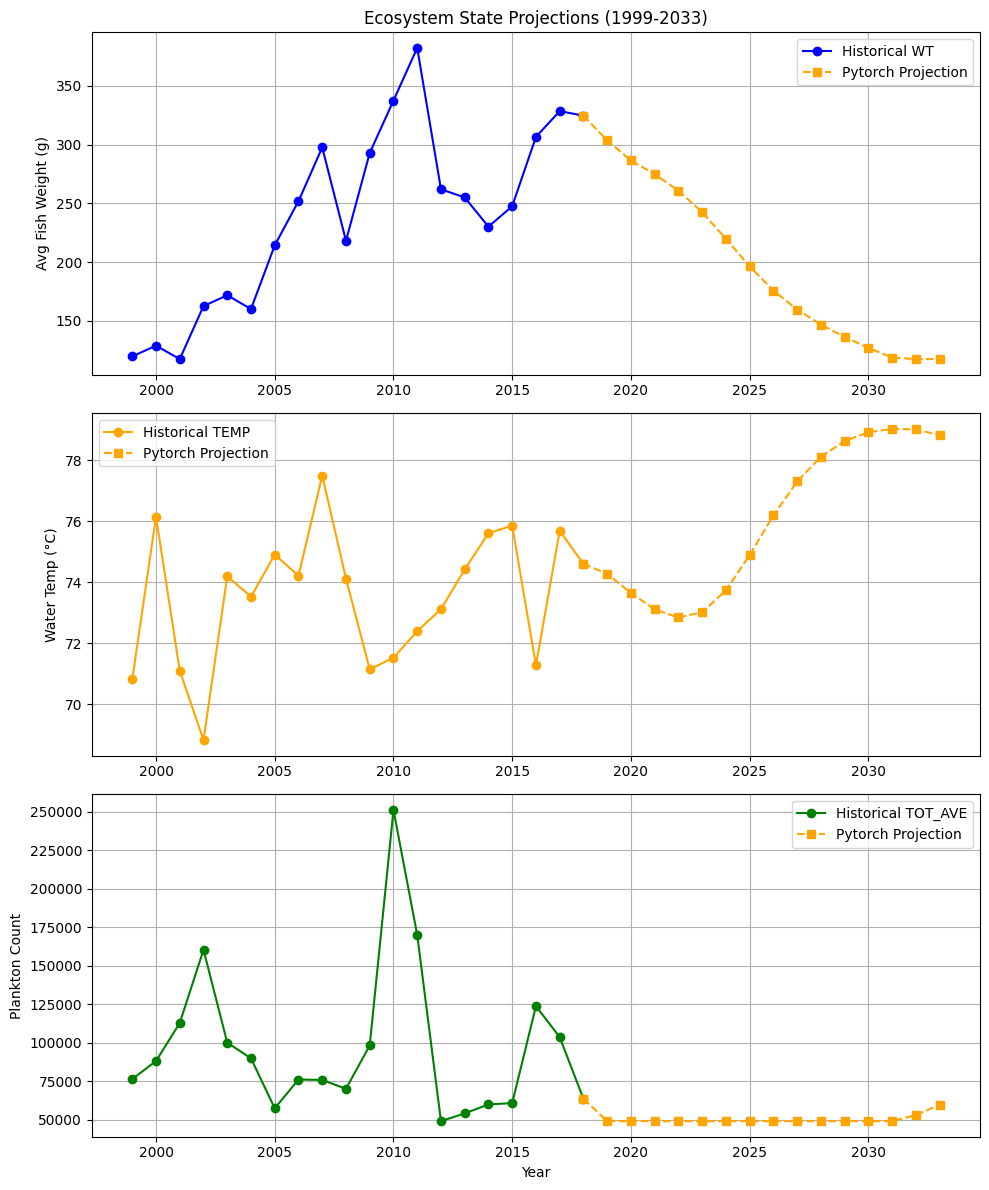

In [196]:
years_hist = ts_recent.index.values
years_proj = np.arange(years_hist[-1], years_hist[-1] + num_future_steps + 1)

fig, axs = plt.subplots(3, 1, figsize=(10, 12))
colors = ['blue', 'orange', 'green']
labels = ['Avg Fish Weight (g)', 'Water Temp (°C)', 'Plankton Count']

for i in range(3):
    axs[i].plot(years_hist, X_data[:, i], '-o', color=colors[i], label=f'Historical {state_cols[i]}')
    axs[i].plot(years_proj, projected_states[:, i], '--s', color='orange', label='Pytorch Projection')
    axs[i].set_ylabel(labels[i])
    axs[i].grid(True)
    axs[i].legend()
    
axs[2].set_xlabel('Year')
axs[0].set_title('Ecosystem State Projections (1999-2033)')
plt.tight_layout()
plt.show()

## **6. Phase Portrait setup**
- Final steps is to create our phase portrait
- Below is the setup to create accurate plots in which can prove whether this can be a predator-prey ODE

In [197]:
print('Generating Phase portrait...')

wt_vals = np.linspace(-0.1, 1.2, 25)
plankton_vals = np.linspace(-0.1, 1.2, 25)
WT_grid, PLANKTON_grid = np.meshgrid(wt_vals, plankton_vals)

mean_temp_norm = X_norm[:, 1].mean()

grid_points = np.column_stack([
    WT_grid.ravel(),
    np.full(WT_grid.size, mean_temp_norm),
    PLANKTON_grid.ravel()
])
grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
with torch.no_grad():
    derivatives = model(grid_tensor).numpy()
    
dU = derivatives[:, 0].reshape(WT_grid.shape)
dV = derivatives[:, 2].reshape(PLANKTON_grid.shape)


Generating Phase portrait...


## **7. Plotting our Portrait**
- This final step will plot our tests to see what will be the expected outcome from our model predicting predator-prey ODE

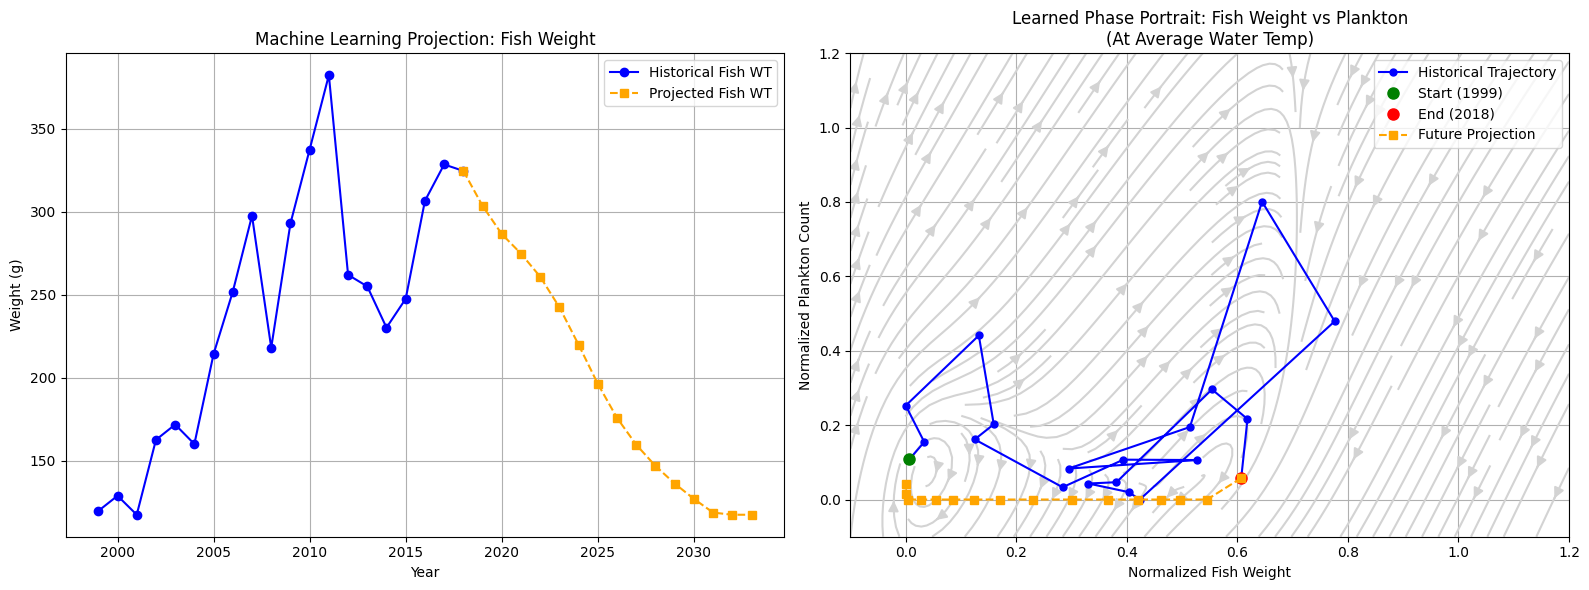

In [198]:
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(121)
years_hist = ts_recent.index.values
years_proj = np.arange(years_hist[-1], years_hist[-1] + num_future_steps + 1)

ax1.plot(years_hist, X_data[:, 0], '-o', color='blue', label='Historical Fish WT')
ax1.plot(years_proj, projected_states[:, 0], '--s', color='orange', label='Projected Fish WT')
ax1.set_title("Machine Learning Projection: Fish Weight")
ax1.set_xlabel("Year")
ax1.set_ylabel("Weight (g)")
ax1.legend()
ax1.grid(True)

ax2 = fig.add_subplot(122)
ax2.streamplot(WT_grid, PLANKTON_grid, dU, dV, color='lightgray', density=1.5, arrowsize=1.5)
ax2.plot(X_norm[:, 0], X_norm[:, 2], '-o', color='blue', label='Historical Trajectory', markersize=5)
ax2.plot(X_norm[0, 0], X_norm[0, 2], 'go', markersize=8, label='Start (1999)')
ax2.plot(X_norm[-1, 0], X_norm[-1, 2], 'ro', markersize=8, label='End (2018)')
ax2.plot(projected_states_norm[:, 0], projected_states_norm[:, 2], '--s', color='orange', label='Future Projection')

ax2.set_title("Learned Phase Portrait: Fish Weight vs Plankton\n(At Average Water Temp)")
ax2.set_xlabel("Normalized Fish Weight")
ax2.set_ylabel("Normalized Plankton Count")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

- As a result, the model shows some similarity with initial data our prediction is producing a circle similar to predator-prey ODEs which proves our theory.

## **8. Final Thoughts and Conclusion**

Our results proved everything I needed to know what is expected to come into the ODE prediction model. Thanks to pyTorch for predicting and projecting an accurate phase portrait and hopefully the fish-plankton populations has similarities in real life from our predicted data.
This is a beginning to other dynamic systems and wish to do more similar to these.
Thus we are complete with this project. EOD